# Libraries

In [1]:
import pandas as pd
import numpy as np

import statistics

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

import pdb

# Dataset preparing

In [4]:
dataset = "datasets/Nursery.csv"
def print_bad_lines(line):
    print(f"Bad line: {line}")

df = pd.read_csv(dataset, on_bad_lines=print_bad_lines, engine='python')

# Define the categories with the desired order
categories = [
    ['usual', 'pretentious', 'great_pret'],  # parents
    ['proper', 'less_proper', 'improper', 'critical', 'very_crit'],  # has_nurs
    ['complete', 'completed', 'incomplete', 'foster'],  # form
    ['1', '2', '3', 'more'],  # children
    ['convenient', 'less_conv', 'critical'],  # housing
    ['convenient', 'inconv'],  # finance
    ['nonprob', 'slightly_prob', 'problematic'],  # social
    ['recommended', 'priority', 'not_recom']  # health
]

# Initialize the OrdinalEncoder with the specified categories
ordinal_encoder = OrdinalEncoder(categories=categories)

classes = df.pop('class')
columns = df.columns

# Fit and transform the data
df = ordinal_encoder.fit_transform(df)

# Convert the result back to a DataFrame for better readability
df = pd.DataFrame(df, columns=columns)
df['class'] = classes
df = df[df['class'] != 'recommend']  # Remove rows where class is 'recommend'

In [2]:
dataset = "datasets/Mfeat_icdm21.csv"

df = pd.read_csv(dataset)
df['class'].unique()

array([2, 5, 4])

In [4]:
dataset = "datasets/Covertype.csv"
def print_bad_lines(line):
    print(f"Bad line: {line}")

df = pd.read_csv(dataset, on_bad_lines=print_bad_lines, engine='python')

scaler = StandardScaler()
df_scaler = scaler.fit_transform(df.drop(columns=['class']))
df_scaler = pd.DataFrame(df_scaler, columns=df.columns.drop('class'))
df_scaler['class'] = df['class']

In [ ]:
dataset = "datasets/Land-use.csv"
def print_bad_lines(line):
    print(f"Bad line: {line}")

df = pd.read_csv(dataset, on_bad_lines=print_bad_lines, engine='python')
df.rename(columns={'Class': 'class'}, inplace=True)

scaler = StandardScaler()
df_scaler = scaler.fit_transform(df.drop(columns=['class']))
df_scaler = pd.DataFrame(df_scaler, columns=df.columns.drop('class'))
df_scaler['class'] = df['class']

In [5]:
df = df_scaler
df

,elevation,aspect,slope,horizontal_distance_to_hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,soil_type_32,soil_type_33,soil_type_34,soil_type_35,soil_type_36,soil_type_37,soil_type_38,soil_type_39,soil_type_40,class
0,-0.728058,-0.084007,-1.217355,-0.564320,-0.767157,-0.356789,0.551178,0.794078,0.091071,-0.967202,...,-0.315782,-0.292638,-0.052722,-0.058148,-0.01312,-0.022529,-0.165469,-0.152438,-0.124875,Lodgepole_Pine
1,0.931641,-1.202527,-0.815816,-0.955355,-0.818815,0.335597,0.103821,-0.018865,0.064956,-0.116609,...,-0.315782,-0.292638,-0.052722,-0.058148,-0.01312,-0.022529,-0.165469,-0.152438,-0.124875,Spruce_Fir
2,0.025053,1.625092,0.254955,-1.073137,-0.681061,1.246159,-1.051852,-0.323718,0.743941,-1.251490,...,-0.315782,-0.292638,-0.052722,-0.058148,-0.01312,-0.022529,-0.165469,-0.152438,-0.124875,Spruce_Fir
3,-2.105786,-1.265164,0.121108,-0.564320,0.317652,-0.859876,-0.268977,-0.780999,-0.143963,-0.882521,...,-0.315782,-0.292638,-0.052722,-0.058148,-0.01312,-0.022529,-0.165469,-0.152438,-0.124875,Douglas_fir
4,-2.112924,0.086008,-1.485047,0.566385,1.884598,-0.757847,0.364779,0.844887,0.299989,-1.056420,...,-0.315782,-0.292638,-0.052722,-0.058148,-0.01312,-0.022529,-0.165469,-0.152438,-0.124875,Douglas_fir
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110388,-2.298525,0.730276,0.388801,0.566385,-0.457212,-0.708436,-0.940013,1.505403,1.501271,-0.880253,...,-0.315782,-0.292638,-0.052722,-0.058148,-0.01312,-0.022529,-0.165469,-0.152438,-0.124875,Cottonwood_Willow
110389,-2.391325,0.256023,-1.351201,-1.271010,-0.801596,-1.376438,0.290220,0.946505,0.378334,-1.169077,...,-0.315782,-0.292638,-0.052722,-0.058148,-0.01312,-0.022529,-0.165469,-0.152438,-0.124875,Cottonwood_Willow
110390,-2.591203,-0.128748,2.396495,-0.870552,0.076583,-0.743088,1.296773,-0.577763,-1.972000,-0.661745,...,-0.315782,-0.292638,-0.052722,-0.058148,-0.01312,-0.022529,-0.165469,-0.152438,-0.124875,Cottonwood_Willow
110391,-2.630464,0.068112,1.727264,-1.271010,-0.801596,-1.031849,0.774857,0.641651,-0.718489,-1.181174,...,-0.315782,-0.292638,-0.052722,-0.058148,-0.01312,-0.022529,-0.165469,-0.152438,-0.124875,Cottonwood_Willow


# Defining easy and hard subclasses for experiment

In [5]:
auc_df = pd.read_csv('processed_results_nursery.csv')
auc_df

,Positive,Negative,Easy,Hard,AUC,AUC_Easy,AUC_Hard
0,['not_recom'],"['priority', 'very_recom']",['very_recom'],['priority'],1.000000,1.000000,1.000000
1,['not_recom'],"['priority', 'very_recom']",['very_recom'],['priority'],1.000000,1.000000,1.000000
2,['not_recom'],"['priority', 'very_recom']",['priority'],['very_recom'],1.000000,1.000000,1.000000
3,['not_recom'],"['priority', 'very_recom']",['very_recom'],['priority'],1.000000,1.000000,1.000000
4,['not_recom'],"['priority', 'very_recom']",['priority'],['very_recom'],1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...
124995,['priority'],"['very_recom', 'spec_prior']",['very_recom'],['spec_prior'],0.898939,0.949360,0.950148
124996,['priority'],"['very_recom', 'spec_prior']",['very_recom'],['spec_prior'],0.898939,0.949360,0.950148
124997,['priority'],"['very_recom', 'spec_prior']",['spec_prior'],['very_recom'],0.898939,0.950148,0.949360
124998,['priority'],"['very_recom', 'spec_prior']",['spec_prior'],['very_recom'],0.898939,0.950148,0.949360


In [6]:
auc_df = pd.read_csv('processed_results_covertype.csv')
auc_df

,Positive,Negative,Easy,Hard,AUC,AUC_Easy,AUC_Hard,Overlap,Overlap_Easy,Overlap_Hard
0,['Douglas_fir'],"['Spruce_Fir', 'Cottonwood_Willow', 'Krummholz...","['Krummholz', 'Spruce_Fir']","['Lodgepole_Pine', 'Cottonwood_Willow', 'Ponde...",0.857207,0.924493,0.841445,0.243204,0.127203,0.328208
1,['Douglas_fir'],"['Spruce_Fir', 'Cottonwood_Willow', 'Krummholz...","['Lodgepole_Pine', 'Ponderosa_Pine']","['Cottonwood_Willow', 'Krummholz', 'Spruce_Fir']",0.857207,0.836516,0.922455,0.243204,0.316952,0.143456
2,['Douglas_fir'],"['Spruce_Fir', 'Cottonwood_Willow', 'Krummholz...","['Lodgepole_Pine', 'Ponderosa_Pine', 'Cottonwo...","['Spruce_Fir', 'Krummholz']",0.857207,0.841445,0.924493,0.243204,0.328208,0.127203
3,['Douglas_fir'],"['Spruce_Fir', 'Cottonwood_Willow', 'Krummholz...","['Lodgepole_Pine', 'Krummholz', 'Ponderosa_Pine']","['Spruce_Fir', 'Cottonwood_Willow']",0.857207,0.845078,0.917531,0.243204,0.307749,0.148543
4,['Douglas_fir'],"['Spruce_Fir', 'Cottonwood_Willow', 'Krummholz...","['Cottonwood_Willow', 'Lodgepole_Pine', 'Ponde...",['Spruce_Fir'],0.857207,0.835426,0.931533,0.243204,0.321058,0.122485
...,...,...,...,...,...,...,...,...,...,...
124995,"['Lodgepole_Pine', 'Cottonwood_Willow', 'Ponde...","['Douglas_fir', 'Aspen']",['Douglas_fir'],['Aspen'],0.805155,0.857207,0.753025,0.431519,0.243204,0.486372
124996,"['Lodgepole_Pine', 'Cottonwood_Willow', 'Ponde...","['Douglas_fir', 'Aspen']",['Douglas_fir'],['Aspen'],0.805155,0.857207,0.753025,0.431519,0.243204,0.486372
124997,"['Lodgepole_Pine', 'Cottonwood_Willow', 'Ponde...","['Douglas_fir', 'Aspen']",['Aspen'],['Douglas_fir'],0.805155,0.753025,0.857207,0.431519,0.486372,0.243204
124998,"['Lodgepole_Pine', 'Cottonwood_Willow', 'Ponde...","['Douglas_fir', 'Aspen']",['Douglas_fir'],['Aspen'],0.805155,0.857207,0.753025,0.431519,0.243204,0.486372


In [9]:
auc_df = pd.read_csv('processed_results_Land-use.csv')
auc_df

,Positive,Negative,Easy,Hard,AUC,AUC_Easy,AUC_Hard,Overlap,Overlap_Easy,Overlap_Hard
0,"['Oats', 'Soybeans', 'Wheat']","['Corn', 'Grass', 'Trees', 'Alfalfa']","['Corn', 'Grass', 'Alfalfa']",['Trees'],0.928555,0.900871,0.999945,0.276877,0.342093,3.239180e-03
1,"['Oats', 'Soybeans', 'Wheat']","['Corn', 'Grass', 'Trees', 'Alfalfa']","['Trees', 'Alfalfa']","['Corn', 'Grass']",0.928555,0.999598,0.912639,0.276877,0.005403,3.055120e-01
2,"['Oats', 'Soybeans', 'Wheat']","['Corn', 'Grass', 'Trees', 'Alfalfa']","['Corn', 'Alfalfa', 'Grass']",['Trees'],0.928555,0.900871,0.999945,0.276877,0.342093,3.239180e-03
3,"['Oats', 'Soybeans', 'Wheat']","['Corn', 'Grass', 'Trees', 'Alfalfa']","['Corn', 'Trees', 'Alfalfa']",['Grass'],0.928555,0.936052,0.998092,0.276877,0.252200,2.430130e-02
4,"['Oats', 'Soybeans', 'Wheat']","['Corn', 'Grass', 'Trees', 'Alfalfa']","['Grass', 'Trees', 'Alfalfa']",['Corn'],0.928555,0.999399,0.941841,0.276877,0.012361,2.328683e-01
...,...,...,...,...,...,...,...,...,...,...
124912,"['Corn', 'Hay']","['Wheat', 'Grass', 'Trees']",['Wheat'],"['Grass', 'Trees']",0.999106,1.000000,0.998680,0.017460,0.000030,2.138136e-02
124913,"['Corn', 'Hay']","['Wheat', 'Grass', 'Trees']",['Grass'],"['Wheat', 'Trees']",0.999106,0.995494,1.000000,0.017460,0.059114,6.995676e-04
124914,"['Corn', 'Hay']","['Wheat', 'Grass', 'Trees']",['Wheat'],"['Grass', 'Trees']",0.999106,1.000000,0.998680,0.017460,0.000030,2.138136e-02
124915,"['Corn', 'Hay']","['Wheat', 'Grass', 'Trees']","['Grass', 'Wheat']",['Trees'],0.999106,0.998596,1.000000,0.017460,0.035713,1.776016e-42


In [6]:
auc_df['diff_AUC'] = abs(auc_df['AUC_Easy'] - auc_df['AUC_Hard'])
auc_df.sort_values(by='diff_AUC', ascending=False, inplace=True)
auc_df

,Positive,Negative,Easy,Hard,AUC,AUC_Easy,AUC_Hard,diff_AUC
12150,['spec_prior'],"['not_recom', 'very_recom', 'priority']",['very_recom'],"['priority', 'not_recom']",0.885614,1.000000,0.883083,0.116917
12151,['spec_prior'],"['not_recom', 'very_recom', 'priority']",['very_recom'],"['priority', 'not_recom']",0.885614,1.000000,0.883083,0.116917
12161,['spec_prior'],"['not_recom', 'very_recom', 'priority']",['very_recom'],"['not_recom', 'priority']",0.885614,1.000000,0.883083,0.116917
12162,['spec_prior'],"['not_recom', 'very_recom', 'priority']","['not_recom', 'priority']",['very_recom'],0.885614,0.883083,1.000000,0.116917
12215,['spec_prior'],"['priority', 'very_recom', 'not_recom']","['priority', 'not_recom']",['very_recom'],0.885614,0.883083,1.000000,0.116917
...,...,...,...,...,...,...,...,...
124937,['not_recom'],"['spec_prior', 'priority']",['priority'],['spec_prior'],1.000000,1.000000,1.000000,0.000000
124936,['not_recom'],"['spec_prior', 'priority']",['spec_prior'],['priority'],1.000000,1.000000,1.000000,0.000000
124949,['not_recom'],"['spec_prior', 'priority']",['priority'],['spec_prior'],1.000000,1.000000,1.000000,0.000000
124948,['not_recom'],"['spec_prior', 'priority']",['spec_prior'],['priority'],1.000000,1.000000,1.000000,0.000000


In [8]:
auc_df['diff_overlap'] = abs(auc_df['Overlap_Easy'] - auc_df['Overlap_Hard'])
auc_df.sort_values(by='diff_overlap', ascending=False, inplace=True)
auc_df

,Positive,Negative,Easy,Hard,AUC,AUC_Easy,AUC_Hard,Overlap,Overlap_Easy,Overlap_Hard,diff_AUC,diff_overlap
88518,"['Aspen', 'Ponderosa_Pine']","['Douglas_fir', 'Cottonwood_Willow', 'Spruce_F...","['Douglas_fir', 'Cottonwood_Willow']",['Spruce_Fir'],0.905333,0.699223,0.943298,0.261769,0.713912,0.154788,0.244075,0.559124
88534,"['Aspen', 'Ponderosa_Pine']","['Douglas_fir', 'Cottonwood_Willow', 'Spruce_F...",['Spruce_Fir'],"['Cottonwood_Willow', 'Douglas_fir']",0.905333,0.943298,0.699223,0.261769,0.154788,0.713912,0.244075,0.559124
88504,"['Aspen', 'Ponderosa_Pine']","['Douglas_fir', 'Cottonwood_Willow', 'Spruce_F...","['Cottonwood_Willow', 'Douglas_fir']",['Spruce_Fir'],0.905333,0.699223,0.943298,0.261769,0.713912,0.154788,0.244075,0.559124
88547,"['Aspen', 'Ponderosa_Pine']","['Douglas_fir', 'Cottonwood_Willow', 'Spruce_F...",['Spruce_Fir'],"['Douglas_fir', 'Cottonwood_Willow']",0.905333,0.943298,0.699223,0.261769,0.154788,0.713912,0.244075,0.559124
88548,"['Aspen', 'Ponderosa_Pine']","['Douglas_fir', 'Cottonwood_Willow', 'Spruce_F...","['Cottonwood_Willow', 'Douglas_fir']",['Spruce_Fir'],0.905333,0.699223,0.943298,0.261769,0.713912,0.154788,0.244075,0.559124
...,...,...,...,...,...,...,...,...,...,...,...,...
34557,['Ponderosa_Pine'],"['Krummholz', 'Lodgepole_Pine', 'Spruce_Fir', ...","['Cottonwood_Willow', 'Krummholz', 'Lodgepole_...","['Douglas_fir', 'Spruce_Fir']",0.927848,0.935102,0.941167,0.135410,0.144481,0.144479,0.006065,0.000001
76226,['Ponderosa_Pine'],"['Douglas_fir', 'Krummholz', 'Lodgepole_Pine',...","['Cottonwood_Willow', 'Krummholz', 'Lodgepole_...","['Douglas_fir', 'Spruce_Fir']",0.927848,0.935102,0.941167,0.135410,0.144481,0.144479,0.006065,0.000001
76228,['Ponderosa_Pine'],"['Douglas_fir', 'Krummholz', 'Lodgepole_Pine',...","['Douglas_fir', 'Spruce_Fir']","['Krummholz', 'Cottonwood_Willow', 'Lodgepole_...",0.927848,0.941167,0.935102,0.135410,0.144479,0.144481,0.006065,0.000001
34560,['Ponderosa_Pine'],"['Krummholz', 'Lodgepole_Pine', 'Spruce_Fir', ...","['Lodgepole_Pine', 'Krummholz', 'Cottonwood_Wi...","['Spruce_Fir', 'Douglas_fir']",0.927848,0.935102,0.941167,0.135410,0.144481,0.144479,0.006065,0.000001


In [7]:
experiment_setup = auc_df.iloc[1]
experiment_setup

Positive                             ['spec_prior']
Negative    ['not_recom', 'very_recom', 'priority']
Easy                                 ['very_recom']
Hard                      ['priority', 'not_recom']
AUC                                        0.885614
AUC_Easy                                        1.0
AUC_Hard                                   0.883083
diff_AUC                                   0.116917
Name: 12151, dtype: object

In [9]:
experiment_setup = auc_df.iloc[0]
experiment_setup

Positive                              ['Aspen', 'Ponderosa_Pine']
Negative        ['Douglas_fir', 'Cottonwood_Willow', 'Spruce_F...
Easy                         ['Douglas_fir', 'Cottonwood_Willow']
Hard                                               ['Spruce_Fir']
AUC                                                      0.905333
AUC_Easy                                                 0.699223
AUC_Hard                                                 0.943298
Overlap                                                  0.261769
Overlap_Easy                                             0.713912
Overlap_Hard                                             0.154788
diff_AUC                                                 0.244075
diff_overlap                                             0.559124
Name: 88518, dtype: object

# Quantifiers (only run)

## Utils

In [3]:
def getTPRandFPRbyThreshold(validation_scores):
    unique_scores = np.arange(0.01, 1.00, 0.01)
    arrayOfTPRandFPRByTr = []

    total_positive = np.sum(validation_scores[:, 1] == 1)
    total_negative = np.sum(validation_scores[:, 1] == 0)

    for threshold in unique_scores:
        fp = np.sum((validation_scores[:, 0] > threshold) & (validation_scores[:, 1] == 0))
        tp = np.sum((validation_scores[:, 0] > threshold) & (validation_scores[:, 1] == 1))
        tpr = tp / total_positive if total_positive > 0 else 0
        fpr = fp / total_negative if total_negative > 0 else 0

        arrayOfTPRandFPRByTr.append([round(threshold, 2), tpr, fpr])

    return np.array(arrayOfTPRandFPRByTr, dtype=object)

In [4]:
def DySyn_distance(x, method="hellinger"):
    if method == "ord":
        x_dif = x[0, :] - x[1, :]
        acum = 0
        aux = 0
        for val in x_dif:
            aux += val
            acum += aux
        return abs(acum)

    if method == "topsoe":
        return sum(x[0, i] * np.log((2 * x[0, i]) / (x[0, i] + x[1, i])) +
                   x[1, i] * np.log((2 * x[1, i]) / (x[1, i] + x[0, i])) for i in range(x.shape[1]))

    if method == "jensen_difference":
        return sum(((x[0, i] * np.log(x[0, i]) + x[1, i] * np.log(x[1, i])) / 2) -
                   ((x[0, i] + x[1, i]) / 2) * np.log((x[0, i] + x[1, i]) / 2) for i in range(x.shape[1]))

    if method == "taneja":
        return sum(((x[0, i] + x[1, i]) / 2) * np.log((x[0, i] + x[1, i]) / (2 * np.sqrt(x[0, i] * x[1, i])))
                   for i in range(x.shape[1]))

    if method == "hellinger":
        return 2 * np.sqrt(1 - sum(np.sqrt(x[0, i] * x[1, i]) for i in range(x.shape[1])))

    if method == "prob_symm":
        return 2 * sum(((x[0, i] - x[1, i]) ** 2) / (x[0, i] + x[1, i]) for i in range(x.shape[1]))

    raise ValueError("measure argument must be a valid option")

def getHist(scores, nbins):
    breaks = np.linspace(0, 1, nbins + 1)
    breaks[-1] = 1.1
    re = np.full(len(breaks) - 1, 1 / (len(breaks) - 1))

    for i in range(1, len(breaks)):
        re[i - 1] = (re[i - 1] + np.sum((scores >= breaks[i - 1]) & (scores < breaks[i]))) / (len(scores) + 1)

    return re

def TernarySearch(left, right, f, eps=1e-4):
    while True:
        if abs(left - right) < eps:
            return (left + right) / 2

        leftThird = left + (right - left) / 3
        rightThird = right - (right - left) / 3

        if f(leftThird) > f(rightThird):
            left = leftThird
        else:
            right = rightThird

In [5]:
def MoSS(n, alpha, m):
    p_score = np.random.uniform(size=int(n * alpha)) ** m
    n_score = 1 - (np.random.uniform(size=int(round(n * (1 - alpha), 0))) ** m)
    scores = np.column_stack((np.concatenate((p_score, n_score)), np.concatenate((np.ones(len(p_score)), np.full(len(n_score), 0)))))
    # pdb.set_trace()
    return scores

MoSS(1000, 0.5, 0.3)

array([[0.90394029, 1.        ],
       [0.57165122, 1.        ],
       [0.4002411 , 1.        ],
       ...,
       [0.1395103 , 0.        ],
       [0.03876261, 0.        ],
       [0.26965593, 0.        ]], shape=(1000, 2))

## Classic quantifiers

In [6]:
def CC(test, thr=0.5):
    result = np.sum(test >= thr) / len(test)
    result = max(0, min(result, 1))

    return np.array([result, 1 - result], dtype=float)

def ACC(test, TprFpr, thr=0.5):
    dC = CC(test)  # Implement CC function separately

    tpr_fpr_row = TprFpr[TprFpr[:, 0] == thr, 1:3].astype(float)
    if tpr_fpr_row.size == 0:
        raise ValueError("Threshold value not found in TprFpr.")

    tpr, fpr = tpr_fpr_row[0]

    result = (dC[0] - fpr) / (tpr - fpr) if (tpr - fpr) != 0 else 0
    result = max(0, min(result, 1))

    return np.array([result, 1 - result], dtype=float)

def DyS(p_score, n_score, test, measure="topsoe", bins=np.arange(2, 22, 2), err=1e-5):
    results = []

    for b_size in bins:
        Sty_1 = getHist(p_score, b_size)  # Implement getHist separately
        Sty_2 = getHist(n_score, b_size)
        Uy = getHist(test, b_size)

        def f(x):
            return DySyn_distance(np.vstack([(Sty_1 * x) + (Sty_2 * (1 - x)), Uy]), method=measure)  # Implement DyS_distance separately

        best_alpha = TernarySearch(0, 1, f, err)  # Implement TernarySearch separately
        results.append(best_alpha)

    result = statistics.median(results)
    result = max(0, min(result, 1))

    return np.array([result, 1 - result])

In [7]:
def X(ts, TprFpr):
    dC = CC(ts)  # Implement CC function separately

    min_index = abs((1 - TprFpr[:, 1]) - TprFpr[:, 2])
    min_index = np.argmin(min_index)

    tpr_fpr_row = TprFpr[min_index, 1:3].astype(float)
    if tpr_fpr_row.size == 0:
        raise ValueError("Threshold value not found in TprFpr.")

    tpr, fpr = tpr_fpr_row

    result = (dC[0] - fpr) / (tpr - fpr) if (tpr - fpr) != 0 else 0
    result = max(0, min(result, 1))

    return np.array([result, 1 - result], dtype=float)

In [8]:
def MAX(ts, TprFpr):
    dC = CC(ts)  # Implement CC function separately

    # Usual MAX implementation
    max_index = abs(TprFpr[:, 1] - TprFpr[:, 2])
    max_index = np.argmax(max_index)

    tpr_fpr_row = TprFpr[max_index, 1:3].astype(float)

    tpr, fpr = tpr_fpr_row

    result = (dC[0] - fpr) / (tpr - fpr) if (tpr - fpr) != 0 else 0
    result = max(0, min(result, 1))

    return np.array([result, 1 - result], dtype=float)

In [9]:
def T50(ts, TprFpr):
    dC = CC(ts)  # Implement CC function separately

    # Usual T50 implementation
    min_index = abs(TprFpr[:, 1] - 0.5)
    min_index = np.argmin(min_index)

    tpr_fpr_row = TprFpr[min_index, 1:3].astype(float)

    tpr, fpr = tpr_fpr_row

    result = (dC[0] - fpr) / (tpr - fpr) if (tpr - fpr) != 0 else 0
    result = max(0, min(result, 1))

    return np.array([result, 1 - result], dtype=float)

In [10]:
def MS(ts, TprFpr):
  results = []
  dC = CC(ts)  # Implement CC function separately

  # Usual MS implementation
  threshold_set = np.arange(0.01, 1.00, 0.01)

  for threshold in threshold_set:
    threshold = round(threshold, 2) # 0.060000003 shenanigans
    tpr, fpr = TprFpr[TprFpr[:, 0] == threshold, 1:3].astype(float)[0]

    result = (dC[0] - fpr) / (tpr - fpr) if (tpr - fpr) != 0 else 0
    result = max(0, min(result, 1))

    results.append(result)

    result = np.median(results)
  return np.array([result, 1 - result], dtype=float)

In [11]:
def MS2(ts, TprFpr):
    results = []

    dC = CC(ts)  # Implement CC function separately

    # Usual MS2 implementation
    index = np.where(abs(TprFpr[:,1]-TprFpr[:,2]) > (1/4))[0].tolist()
    threshold_set = TprFpr[index,0]
    if threshold_set.shape[0] == 0:
      threshold_set = np.arange(0.01, 1.00, 0.01)

    # else usual MS
    for threshold in threshold_set:
      threshold = round(threshold, 2) # 0.060000003 shenanigans
      tpr, fpr = TprFpr[TprFpr[:, 0] == threshold, 1:3].astype(float)[0]

      result = (dC[0] - fpr) / (tpr - fpr) if (tpr - fpr) != 0 else 0
      result = max(0, min(result, 1))

      results.append(result)

    result = np.median(results)
    return np.array([result, 1 - result], dtype=float)

In [12]:
def SMM(p_scores, n_scores, t_scores):
  mean_p_scores = np.mean(p_scores)
  mean_n_scores = np.mean(n_scores)
  mean_t_scores = np.mean(t_scores)

  alpha = (mean_t_scores - mean_n_scores) / (mean_p_scores - mean_n_scores)
  alpha = max(0, min(alpha, 1))

  return np.round([alpha, abs(1-alpha)], 2)

## Synthetic quantifiers

In [45]:
def DySyn(ts, measure, MF=np.arange(0.1, 1.0, 0.1)):
    MF = np.round(MF, 2)

    results = []
    distances = []

    for mf in MF:
        scores = MoSS(1000, 0.5, mf)  # Implement MoSS function separately
        test_p = scores[scores[:, 1] == 1, 0]
        test_n = scores[scores[:, 1] == 0, 0]

        if measure == "sord":
            rQnt = DySyn_SORD(test_p, test_n, ts)  # Implement DySyn_SORD separately
        else:
            rQnt = DySyn_DyS(test_p, test_n, ts, measure)  # Implement DySyn_DyS separately

        distances.append(rQnt[1])
        results.append(rQnt[0][0])

    best_result = round(results[np.argmin(distances)], 2)
    return [np.array([best_result, 1 - best_result]), min(distances), MF[np.argmin(distances)]]

def DySyn_DyS(p_score, n_score, test, measure="hellinger", b_sizes = list(range(2, 21, 2)) + [30]):
    results = []
    vDistAll = []

    for b_size in b_sizes:
        Sty_1 = getHist(p_score, b_size)  # Implement getHist separately
        Sty_2 = getHist(n_score, b_size)
        Uy = getHist(test, b_size)

        def f(x):
            return DySyn_distance(np.vstack([(Sty_1 * x) + (Sty_2 * (1 - x)), Uy]), method=measure)  # Implement DySyn_distance separately

        best_alpha = TernarySearch(0, 1, f, 1e-2)  # Implement TernarySearch separately
        results.append(best_alpha)
        vDistAll.append(f(best_alpha))

    median_result = np.median(results)
    return [np.array([round(median_result, 2), 1 - round(median_result, 2)]), min(vDistAll)]

def PNTDiff(pos, neg, test, pos_prop):
    p_w = pos_prop / len(pos)
    n_w = (1 - pos_prop) / len(neg)
    t_w = -1 / len(test)

    p = np.column_stack((pos, np.full(len(pos), p_w)))
    n = np.column_stack((neg, np.full(len(neg), n_w)))
    t = np.column_stack((test, np.full(len(test), t_w)))

    v = np.vstack((p, n, t))
    v = v[v[:, 0].argsort()]

    acc = v[0, 1]
    total_cost = 0

    for i in range(1, len(v)):
        cost_mul = v[i, 0] - v[i - 1, 0]
        total_cost += abs(cost_mul * acc)
        acc += v[i, 1]

    return total_cost

def DySyn_SORD(p_score, n_score, test):
    def f(x):
        return PNTDiff(p_score, n_score, test, x)

    best_alpha = TernarySearch(0, 1, f, 1e-5)  # Implement TernarySearch separately
    vDist = f(best_alpha)

    return [np.array([round(best_alpha, 2), 1 - round(best_alpha, 2)]), vDist]

In [14]:
def ACCSyn(ts, measure, MF_dysyn):
    rQnt = DySyn(ts, measure, MF_dysyn)
    TprFpr = np.array(getTPRandFPRbyThreshold(MoSS(1000, 0.5, rQnt[2]))).astype(float)  # Implement getTPRandFPRbyThreshold


    dC = CC(ts)  # Implement CC function separately

    tpr_fpr_row = TprFpr[TprFpr[:, 0] == 0.5, 1:3].astype(float)
    # pdb.set_trace()
    if tpr_fpr_row.size == 0:
        raise ValueError("Threshold value not found in TprFpr.")

    tpr, fpr = tpr_fpr_row[0]

    result = (dC[0] - fpr) / (tpr - fpr) if (tpr - fpr) != 0 else 0
    result = max(0, min(result, 1))

    return np.array([result, 1 - result], dtype=float)

In [15]:
def XSyn(ts, measure, MF_dysyn):
    rQnt = DySyn(ts, measure, MF_dysyn)
    TprFpr = np.array(getTPRandFPRbyThreshold(MoSS(1000, 0.5, rQnt[2]))).astype(float)
    
    dC = CC(ts)  # Implement CC function separately

    # Usual X implementation
    min_index = abs((1 - TprFpr[:, 1]) - TprFpr[:, 2])
    min_index = np.argmin(min_index)

    tpr_fpr_row = TprFpr[min_index, 1:3].astype(float)
    # if tpr_fpr_row.size == 0:
    #   raise ValueError("Threshold value not found in TprFpr.")

    tpr, fpr = tpr_fpr_row

    result = (dC[0] - fpr) / (tpr - fpr) if (tpr - fpr) != 0 else 0
    result = max(0, min(result, 1))

    return np.array([result, 1 - result], dtype=float)

In [16]:
def MAXSyn(ts, measure, MF_dysyn):
    rQnt = DySyn(ts, measure, MF_dysyn)
    TprFpr = np.array(getTPRandFPRbyThreshold(MoSS(1000, 0.5, rQnt[2]))).astype(float)
    
    dC = CC(ts)  # Implement CC function separately

    # Usual MAX implementation
    max_index = abs(TprFpr[:, 1] - TprFpr[:, 2])
    max_index = np.argmax(max_index)

    tpr_fpr_row = TprFpr[max_index, 1:3].astype(float)

    tpr, fpr = tpr_fpr_row

    result = (dC[0] - fpr) / (tpr - fpr) if (tpr - fpr) != 0 else 0
    result = max(0, min(result, 1))

    return np.array([result, 1 - result], dtype=float)

In [17]:
def T50Syn(ts, measure, MF_dysyn):
    rQnt = DySyn(ts, measure, MF_dysyn)
    TprFpr = np.array(getTPRandFPRbyThreshold(MoSS(1000, 0.5, rQnt[2]))).astype(float)

    dC = CC(ts)  # Implement CC function separately

    # Usual T50 implementation
    min_index = abs(TprFpr[:, 1] - 0.5)
    min_index = np.argmin(min_index)

    tpr_fpr_row = TprFpr[min_index, 1:3].astype(float)

    tpr, fpr = tpr_fpr_row

    result = (dC[0] - fpr) / (tpr - fpr) if (tpr - fpr) != 0 else 0
    result = max(0, min(result, 1))

    return np.array([result, 1 - result], dtype=float)

In [18]:
def MSSyn(ts, measure, MF_dysyn):
    results = []

    rQnt = DySyn(ts, measure, MF_dysyn)
    TprFpr = np.array(getTPRandFPRbyThreshold(MoSS(1000, 0.5, rQnt[2]))).astype(float)

    dC = CC(ts)  # Implement CC function separately

    # Usual MS implementation
    threshold_set = np.arange(0.01, 1.00, 0.01)

    for threshold in threshold_set:
      threshold = round(threshold, 2) # 0.060000003 shenanigans
      tpr, fpr = TprFpr[TprFpr[:, 0] == threshold, 1:3].astype(float)[0]

      result = (dC[0] - fpr) / (tpr - fpr) if (tpr - fpr) != 0 else 0
      result = max(0, min(result, 1))

      results.append(result)

    result = np.median(results)
    return np.array([result, 1 - result], dtype=float)

In [19]:
def MS2Syn(ts, measure, MF_dysyn):
    results = []

    rQnt = DySyn(ts, measure, MF_dysyn)
    TprFpr = np.array(getTPRandFPRbyThreshold(MoSS(1000, 0.5, rQnt[2]))).astype(float)
    
    dC = CC(ts)  # Implement CC function separately

    # Usual MS2 implementation
    index = np.where(abs(TprFpr[:,1]-TprFpr[:,2]) > (1/4))[0].tolist()
    threshold_set = TprFpr[index,0]
    if threshold_set.shape[0] == 0:
      threshold_set = np.arange(0.01, 1.00, 0.01)

    # else usual MS
    for threshold in threshold_set:
      threshold = round(threshold, 2) # 0.060000003 shenanigans
      tpr, fpr = TprFpr[TprFpr[:, 0] == threshold, 1:3].astype(float)[0]

      result = (dC[0] - fpr) / (tpr - fpr) if (tpr - fpr) != 0 else 0
      result = max(0, min(result, 1))

      results.append(result)

    result = np.median(results)
    return np.array([result, 1 - result], dtype=float)

In [20]:
def SMMSyn(ts, measure, MF_dysyn):
    rQnt = DySyn(ts, measure, MF_dysyn)
    best_scores = MoSS(1000, 0.5, rQnt[2]) # sempre NaN em 0 de distances

    best_p = best_scores[best_scores[:, 2] == 1, 0]
    best_n = best_scores[best_scores[:, 2] == 2, 0]
    result = SMM(best_p, best_n, ts)

    return result

# Binarizing experiment between Positive and Negative (Easy and Hard)

In [8]:
experiment_setup

Positive                             ['spec_prior']
Negative    ['not_recom', 'very_recom', 'priority']
Easy                                 ['very_recom']
Hard                      ['priority', 'not_recom']
AUC                                        0.885614
AUC_Easy                                        1.0
AUC_Hard                                   0.883083
diff_AUC                                   0.116917
Name: 12151, dtype: object

In [80]:
experiment_setup['Negative']

"['not_recom', 'very_recom', 'priority']"

In [81]:
df['class'].value_counts()

class
0    8914
1    4044
Name: count, dtype: int64

In [30]:
df['binary'] = df['class'].map(lambda x: 1 if x in ['Oats'] else 0)
df['difficulty'] = df['class'].map(lambda x: 'Easy' if x in ['Hay'] else ('Hard' if x in ['Soybeans', 'Corn', 'Alfalfa', 'Trees'] else 'Positive'))
df['class'] = df['binary']
df.drop(columns=['binary'], inplace=True)
df

,elevation,aspect,slope,horizontal_distance_to_hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,soil_type_33,soil_type_34,soil_type_35,soil_type_36,soil_type_37,soil_type_38,soil_type_39,soil_type_40,class,difficulty
0,2754,146,5,150,2,1790,227,239,146,700,...,0,0,0,0,0,0,0,0,0,Positive
1,3219,21,8,67,-1,2869,215,223,145,1825,...,0,0,0,0,0,0,0,0,0,Positive
2,2965,337,16,42,7,4288,184,217,171,324,...,0,0,0,0,0,0,0,0,0,Positive
3,2368,14,15,150,65,1006,205,208,137,812,...,0,0,0,0,0,0,0,0,0,Positive
4,2366,165,3,390,156,1165,222,240,154,582,...,0,0,0,0,0,0,0,0,0,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110388,2314,237,17,390,20,1242,187,253,200,815,...,0,0,0,0,0,0,0,0,0,Positive
110389,2288,184,4,0,0,201,220,242,157,433,...,0,0,0,0,0,0,0,0,0,Positive
110390,2232,141,32,85,51,1188,247,212,67,1104,...,0,0,0,0,0,0,0,0,0,Positive
110391,2221,163,27,0,0,738,233,236,115,417,...,0,0,0,0,0,0,0,0,0,Positive


In [18]:
df['binary'] = df['class'].map(lambda x: 1 if x in ['Aspen', 'Ponderosa_Pine'] else 0)
df['difficulty'] = df['class'].map(lambda x: 'Easy' if x == 'Spruce_Fir' else ('Hard' if x in ['Douglas_fir', 'Cottonwood_Willow'] else 'Positive'))
df['class'] = df['binary']
df.drop(columns=['binary'], inplace=True)
df

,elevation,aspect,slope,horizontal_distance_to_hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,soil_type_33,soil_type_34,soil_type_35,soil_type_36,soil_type_37,soil_type_38,soil_type_39,soil_type_40,class,difficulty
0,-0.728058,-0.084007,-1.217355,-0.564320,-0.767157,-0.356789,0.551178,0.794078,0.091071,-0.967202,...,-0.292638,-0.052722,-0.058148,-0.01312,-0.022529,-0.165469,-0.152438,-0.124875,0,Positive
1,0.931641,-1.202527,-0.815816,-0.955355,-0.818815,0.335597,0.103821,-0.018865,0.064956,-0.116609,...,-0.292638,-0.052722,-0.058148,-0.01312,-0.022529,-0.165469,-0.152438,-0.124875,0,Easy
2,0.025053,1.625092,0.254955,-1.073137,-0.681061,1.246159,-1.051852,-0.323718,0.743941,-1.251490,...,-0.292638,-0.052722,-0.058148,-0.01312,-0.022529,-0.165469,-0.152438,-0.124875,0,Easy
3,-2.105786,-1.265164,0.121108,-0.564320,0.317652,-0.859876,-0.268977,-0.780999,-0.143963,-0.882521,...,-0.292638,-0.052722,-0.058148,-0.01312,-0.022529,-0.165469,-0.152438,-0.124875,0,Hard
4,-2.112924,0.086008,-1.485047,0.566385,1.884598,-0.757847,0.364779,0.844887,0.299989,-1.056420,...,-0.292638,-0.052722,-0.058148,-0.01312,-0.022529,-0.165469,-0.152438,-0.124875,0,Hard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110388,-2.298525,0.730276,0.388801,0.566385,-0.457212,-0.708436,-0.940013,1.505403,1.501271,-0.880253,...,-0.292638,-0.052722,-0.058148,-0.01312,-0.022529,-0.165469,-0.152438,-0.124875,0,Hard
110389,-2.391325,0.256023,-1.351201,-1.271010,-0.801596,-1.376438,0.290220,0.946505,0.378334,-1.169077,...,-0.292638,-0.052722,-0.058148,-0.01312,-0.022529,-0.165469,-0.152438,-0.124875,0,Hard
110390,-2.591203,-0.128748,2.396495,-0.870552,0.076583,-0.743088,1.296773,-0.577763,-1.972000,-0.661745,...,-0.292638,-0.052722,-0.058148,-0.01312,-0.022529,-0.165469,-0.152438,-0.124875,0,Hard
110391,-2.630464,0.068112,1.727264,-1.271010,-0.801596,-1.031849,0.774857,0.641651,-0.718489,-1.181174,...,-0.292638,-0.052722,-0.058148,-0.01312,-0.022529,-0.165469,-0.152438,-0.124875,0,Hard


In [32]:
df['binary'] = df['class'].map(lambda x: 1 if x == 'Cottonwood_Willow' else 0)
df['difficulty'] = df['class'].map(lambda x: 'Easy' if x == 'Krummholz' else ('Hard' if x in ['Ponderosa_Pine', 'Lodgepole_Pine', 'Aspen', 'Spruce_Fir'] else 'Positive'))
df['class'] = df['binary']
df.drop(columns=['binary'], inplace=True)
df

,elevation,aspect,slope,horizontal_distance_to_hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,soil_type_33,soil_type_34,soil_type_35,soil_type_36,soil_type_37,soil_type_38,soil_type_39,soil_type_40,class,difficulty
0,2754,146,5,150,2,1790,227,239,146,700,...,0,0,0,0,0,0,0,0,0,Positive
1,3219,21,8,67,-1,2869,215,223,145,1825,...,0,0,0,0,0,0,0,0,0,Positive
2,2965,337,16,42,7,4288,184,217,171,324,...,0,0,0,0,0,0,0,0,0,Positive
3,2368,14,15,150,65,1006,205,208,137,812,...,0,0,0,0,0,0,0,0,0,Positive
4,2366,165,3,390,156,1165,222,240,154,582,...,0,0,0,0,0,0,0,0,0,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110388,2314,237,17,390,20,1242,187,253,200,815,...,0,0,0,0,0,0,0,0,0,Positive
110389,2288,184,4,0,0,201,220,242,157,433,...,0,0,0,0,0,0,0,0,0,Positive
110390,2232,141,32,85,51,1188,247,212,67,1104,...,0,0,0,0,0,0,0,0,0,Positive
110391,2221,163,27,0,0,738,233,236,115,417,...,0,0,0,0,0,0,0,0,0,Positive


In [9]:
df['binary'] = df['class'].map(lambda x: 1 if x == 'spec_prior' else (0 if x in ['priority', 'not_recom', 'very_recom'] else None))
df['difficulty'] = df['class'].map(lambda x: 'Easy' if x == 'very_recom' else ('Hard' if x in ['priority', 'not_recom'] else 'Positive'))
df['class'] = df['binary']
df.drop(columns=['binary'], inplace=True)
df

,parents,has_nurs,form,children,housing,finance,social,health,class,difficulty
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,Hard
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0,Hard
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0,Hard
5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0,Hard
6,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0,Hard
...,...,...,...,...,...,...,...,...,...,...
12955,2.0,4.0,3.0,3.0,2.0,1.0,1.0,1.0,1,Positive
12956,2.0,4.0,3.0,3.0,2.0,1.0,1.0,2.0,0,Hard
12957,2.0,4.0,3.0,3.0,2.0,1.0,2.0,0.0,1,Positive
12958,2.0,4.0,3.0,3.0,2.0,1.0,2.0,1.0,1,Positive


In [34]:
df['class'].value_counts()

Series([], Name: count, dtype: int64)

In [35]:
df[df['difficulty'] == 'Easy'].shape[0], df[df['difficulty'] == 'Hard'].shape[0]

(0, 0)

In [21]:
df['binary'] = df['class'].map(lambda x: 1 if x == 5 else (0 if x in [2, 4] else None))
df['difficulty'] = df['class'].map(lambda x: 'Easy' if x == 2 else ('Hard' if x in [4] else 'Positive'))
df['class'] = df['binary']
df.drop(columns=['binary'], inplace=True)
df

,class,att1,att2,att3,att4,att5,att6,difficulty
0,0,0,2,0,136.194861,1.452134,3334.110374,Easy
1,0,0,2,0,136.806861,1.444288,3560.921530,Easy
2,0,0,2,0,130.084861,1.576239,3396.473985,Easy
3,0,0,3,1,144.026861,1.495583,5471.785750,Easy
4,0,0,3,1,141.470861,1.515987,5416.707511,Easy
...,...,...,...,...,...,...,...,...
1595,0,1,1,1,157.498861,1.655794,5326.025889,Easy
1596,0,1,1,1,152.404861,1.620345,5243.267754,Easy
1597,0,1,1,1,134.672861,1.541987,3766.763222,Easy
1598,0,1,1,1,142.926861,1.426381,4118.327320,Easy


## Variables

In [36]:
replicates = 1

test_sizes = [100]
pos_props = np.linspace(0, 1.0, 6)
hard_props = np.linspace(0, 1.0, 6)

quantifiers = []
model = None
pos_props

array([0. , 0.2, 0.4, 0.6, 0.8, 1. ])

## Experiment

### Model training

In [37]:
df['difficulty'].value_counts(), df['difficulty'].value_counts(normalize=True)

(difficulty
 Positive    110393
 Name: count, dtype: int64,
 difficulty
 Positive    1.0
 Name: proportion, dtype: float64)

In [38]:
# TENHO QUE BINARIZAR CLASSES! (FACEIS VIRAM EASY, DIFICEIS VIRAM HARD)

train, test = train_test_split(df, test_size=0.33, stratify=df['difficulty'], random_state=40)


In [39]:
train['difficulty'].value_counts(), train['difficulty'].value_counts(normalize=True), test['difficulty'].value_counts(), test['difficulty'].value_counts(normalize=True)

(difficulty
 Positive    73963
 Name: count, dtype: int64,
 difficulty
 Positive    1.0
 Name: proportion, dtype: float64,
 difficulty
 Positive    36430
 Name: count, dtype: int64,
 difficulty
 Positive    1.0
 Name: proportion, dtype: float64)

In [40]:
minority_class_count = train[train['difficulty'] == 'Easy'].shape[0]
minority_class_count

0

In [41]:
def get_batch(df, hard_prop):

    df_neg = df[df['class'] == 'Negative']
    df_neg = 
    minority_class_count = 



SyntaxError: invalid syntax (3832921258.py, line 4)

In [ ]:
# TENHO QUE BINARIZAR CLASSES! (FACEIS VIRAM EASY, DIFICEIS VIRAM HARD)

X = df.drop(columns=['class', 'difficulty'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify=y, random_state=40)
model = LogisticRegression()

model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)
y_pred_proba = pd.DataFrame(y_pred_proba, columns=model.classes_)
y_pred_proba

,Negative,Positive
0,0.987338,0.012662
1,0.991244,0.008756
2,0.986853,0.013147
3,0.770417,0.229583
4,0.992955,0.007045
...,...,...
4272,0.947275,0.052725
4273,0.401036,0.598964
4274,0.917272,0.082728
4275,0.558611,0.441389


In [ ]:

for test_size in test_sizes:
    for pos_prop in pos_props:
        for hard_prop in hard_props:
            for replicate in replicates:




                





# Experiment Real Datasets (use this one!)

In [22]:
df

,class,att1,att2,att3,att4,att5,att6,difficulty
0,0,0,2,0,136.194861,1.452134,3334.110374,Easy
1,0,0,2,0,136.806861,1.444288,3560.921530,Easy
2,0,0,2,0,130.084861,1.576239,3396.473985,Easy
3,0,0,3,1,144.026861,1.495583,5471.785750,Easy
4,0,0,3,1,141.470861,1.515987,5416.707511,Easy
...,...,...,...,...,...,...,...,...
1595,0,1,1,1,157.498861,1.655794,5326.025889,Easy
1596,0,1,1,1,152.404861,1.620345,5243.267754,Easy
1597,0,1,1,1,134.672861,1.541987,3766.763222,Easy
1598,0,1,1,1,142.926861,1.426381,4118.327320,Easy


In [23]:
import pdb
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier


def getScores(dt, label, folds, model):

    skf = StratifiedKFold(n_splits=folds)
    results = []
    class_labl = []

    for fold_i, (train_index,valid_index) in enumerate(skf.split(dt,label)):

        tr_data = pd.DataFrame(dt.iloc[train_index])   #Train data and labels
        tr_lbl = label.iloc[train_index]

        valid_data = pd.DataFrame(dt.iloc[valid_index])  #Validation data and labels
        valid_lbl = label.iloc[valid_index]

        model.fit(tr_data, tr_lbl)

        results.extend(model.predict_proba(valid_data)[:,1])     #evaluating scores
        class_labl.extend(valid_lbl)

    scr = pd.DataFrame(results,columns=["score"])
    scr_labl = pd.DataFrame(class_labl, columns= ["class"])
    scores = pd.concat([scr,scr_labl], axis = 1, ignore_index= False)

    return scores

def get_batch(dts, num_pos, num_E, num_H):

    pos_samples = dts[dts['difficulty'] == 'Positive'].sample(n=num_pos, replace=False)
    E_samples = dts[dts['difficulty'] == 'Easy'].sample(n=num_E, replace=False)
    H_samples = dts[dts['difficulty'] == 'Hard'].sample(n=num_H, replace=False)

    batch = pd.concat([pos_samples, E_samples, H_samples]).sample(frac=1).reset_index(drop=True)
    return batch

In [49]:
def apply_qntMethod(qntMethod, p_score, n_score, test, TprFpr=None, thr=None, measure="topsoe", MF_dysyn=np.arange(0.1, 1.0, 0.1)):
    import mlquantify  # Ensure the mlquantify package is available
    
    # MF_dysyn = np.arange(0.3,0.7,0.1)
    # MF_dysyn = np.round(MF_dysyn, 2)

    if qntMethod == "CC":
        return CC(test=test, thr=thr)

    if qntMethod == "ACCSyn":
        return ACCSyn(ts=test, measure=measure, MF_dysyn=MF_dysyn)

    if qntMethod == "XSyn":
        return XSyn(ts=test, measure=measure, MF_dysyn=MF_dysyn)

    if qntMethod == "MAXSyn":
        return MAXSyn(ts=test, measure=measure, MF_dysyn=MF_dysyn)

    if qntMethod == "T50Syn":
        return T50Syn(ts=test, measure=measure, MF_dysyn=MF_dysyn)

    if qntMethod == "MSSyn":
        return MSSyn(ts=test, measure=measure, MF_dysyn=MF_dysyn)

    if qntMethod == "MS2Syn":
        return MS2Syn(ts=test, measure=measure, MF_dysyn=MF_dysyn)

    if qntMethod == "SMMSyn":
        return SMMSyn(ts=test, measure=measure, MF_dysyn=MF_dysyn)

    if qntMethod == "PCC":
        return mlquantify.PCC(test)

    if qntMethod == "ACC":
        return ACC(test=test, TprFpr=TprFpr, thr=thr)

    if qntMethod == "T50":
        return T50(ts=test, TprFpr=TprFpr)

    if qntMethod == "X":
        return X(ts=test, TprFpr=TprFpr)

    if qntMethod == "MAX":
        return MAX(ts=test, TprFpr=TprFpr)

    if qntMethod == "PACC":
        return mlquantify.methods.PACC(ts=test, TprFpr=TprFpr, thr=thr)

    if qntMethod == "DySyn":
        return DySyn(ts=test, measure=measure, MF=MF_dysyn)

    if qntMethod == "HDy-LP":
        return mlquantify.HDy_LP(p_score=p_score, n_score=n_score, test=test)

    if qntMethod == "DyS":
        return DyS(p_score=p_score, n_score=n_score, test=test, measure=measure)

    if qntMethod == "SORD":
        return mlquantify.SORD(p_score=p_score, n_score=n_score, test=test)

    if qntMethod == "MS":
        return MS(ts=test, TprFpr=TprFpr)

    if qntMethod == "MS2":
        return MS2(ts=test, TprFpr=TprFpr)

    if qntMethod == "SMM":
        return SMM(p_scores=p_score, n_scores=n_score, t_scores=test)

    print("ERROR - Quantification method was not applied!")
    return None

In [48]:
# prompt: consider an array composed with 0s or 1s and sometimes only 0s or only 1s provide as result the proportion between 0s and 1s

import numpy as np
def calculate_proportion(arr):
    """Calculates the proportion of 0s and 1s in a binary array.

    Args:
    arr: A list or numpy array containing only 0s and 1s.

    Returns:
    A dictionary containing the proportions of 0s and 1s,
    or None if the input is invalid.
    """
    if not isinstance(arr, (list, np.ndarray)):
        print("Error: Input must be a list or numpy array.")
        return None

    neg = arr.count(0) if isinstance(arr, list) else np.count_nonzero(arr == 0)
    pos = arr.count(1) if isinstance(arr, list) else np.count_nonzero(arr == 1)
    total = len(arr)

    if total == 2:
        print("Error: Input array is empty.")
        return None

    if neg + pos != total:
        print("Error: Input array must contain only 0s and 1s.")
        return None

    proportion_pos = pos / total

    return [proportion_pos, 1-proportion_pos]


In [26]:
def balanced_train_test_split(df, group_col='difficulty', test_size=0.5, random_state=None):
    # Find the minimum count among the groups
    min_count = df[group_col].value_counts().min()
    # Sample min_count from each group
    df_balanced = df.groupby(group_col).sample(n=min_count, random_state=random_state)
    # Now split, stratifying by group_col (which is now balanced)
    train, test = train_test_split(
        df_balanced,
        stratify=df_balanced[group_col],
        test_size=test_size,
        random_state=random_state
    )
    return train, test

In [37]:
df

,class,att1,att2,att3,att4,att5,att6,difficulty
0,0,0,2,0,136.194861,1.452134,3334.110374,Easy
1,0,0,2,0,136.806861,1.444288,3560.921530,Easy
2,0,0,2,0,130.084861,1.576239,3396.473985,Easy
3,0,0,3,1,144.026861,1.495583,5471.785750,Easy
4,0,0,3,1,141.470861,1.515987,5416.707511,Easy
...,...,...,...,...,...,...,...,...
1595,0,1,1,1,157.498861,1.655794,5326.025889,Easy
1596,0,1,1,1,152.404861,1.620345,5243.267754,Easy
1597,0,1,1,1,134.672861,1.541987,3766.763222,Easy
1598,0,1,1,1,142.926861,1.426381,4118.327320,Easy


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from tqdm.notebook import tqdm

def run_over_real_dataset(dataset, replicates=3):
    batch_size = 100
    qnt = [
        #    'T50',
        #    'T50Syn-TS',
        #    'MS',
        #    'MSSyn-PS',
        #    'MS2',
        #    'MS2Syn-TS',
        #    'SMM',
        #    'SMMSyn-TS',
        #    'DyS',
        #    'DySyn',
        #    'X',
        #    'XSyn-TS',
        #    'MAX',
        #    'MAXSyn-TS',
           'ACC',
           'ACCSyn',
           'CC'
           ]

    vdist = {"TS": "topsoe", "JD": "jensen_difference", "PS": "prob_symm", "ORD": "ord", "SORD": "sord", "TN": "taneja", "HD": "hellinger"}

    results = []

    # Splitting to get training and test partition
    # train, test = train_test_split(dataset, stratify=dataset['difficulty'], test_size=0.5)

    train, test = balanced_train_test_split(dataset, group_col='difficulty', test_size=0.5)#, random_state=42)

    # From training set get a sample to be the training set with 50% of positives and negatives (25% hard and 25% easy negative subclasses)
    # Note: the amount of instances is restricted to the class that has less instances
    train = get_batch(train, train['difficulty'].value_counts().min(), train['difficulty'].value_counts().min(), train['difficulty'].value_counts().min())

    # From test set get a sample to be the test set with 50% of positives and negatives (25% hard and 25% easy negative subclasses)
    # Note: the amount of instances is restricted to the class that has less instances
    test = get_batch(test, test['difficulty'].value_counts().min(), test['difficulty'].value_counts().min(), test['difficulty'].value_counts().min())

    # pdb.set_trace()

    model = RandomForestClassifier(n_estimators=200) 

    scores = np.array(getScores(train.drop(columns=['class', 'difficulty']),  train['class'], 10, model))

    TprFpr = np.array(getTPRandFPRbyThreshold(scores)).astype(float)  # Implement getTPRandFPRbyThreshold

    model.fit(train.drop(columns=['class', 'difficulty']), train['class'])

    for pos_ratio in tqdm(np.linspace(0.0, 1.0, 21), desc="Outer Loop"):  # Varying positive/negative ratio
        num_pos = int(batch_size * pos_ratio)
        num_neg = batch_size - num_pos

        for neg_ratio in np.linspace(0.0, 1.0, 5):  # Varying E/H distribution in negative
            num_E = int(num_neg * neg_ratio)
            num_H = num_neg - num_E

            for _ in range(replicates):
                batch = get_batch(test, num_pos, num_E, num_H)
                print(len(batch))

                # pdb.set_trace()

                for qi in qnt:
                    qntMethod = qi.split("-")[0] if "-" in qi else qi
                    if qntMethod != "HDy-LP":
                        try:
                            nk = int(qntMethod.split("_")[0])
                        except ValueError:
                            nk = 1
                        qntMethod = "DySyn" if nk != 1 else qntMethod

                    measure = None
                    if len(qi.split("-")) > 1:
                        measure = vdist.get(qi.split("-")[1])

                    test_scores = model.predict_proba(batch.drop(columns=['class', 'difficulty']))
                    test_scores_pos = test_scores[:,1]

                    # pdb.set_trace()

                    qnt_re = apply_qntMethod(qntMethod=qntMethod,
                                                p_score=scores[scores[:, 1] == 1, 0],
                                                n_score=scores[scores[:, 1] == 0, 0],
                                                test=test_scores_pos,
                                                TprFpr=TprFpr,
                                                thr=0.5) # Implement apply_qntMethod

                    freq_REAL = calculate_proportion(batch['class'].tolist())[0]
                    if qntMethod == "DySyn":
                        freq_PRE = np.round(qnt_re[0][0], 3)
                    else:
                        freq_PRE = np.round(qnt_re[0],3)

                    results.append([pos_ratio,  # P - Positives distr.
                                    neg_ratio,  # E - Easy Negative distr.
                                    1-neg_ratio,# H - Hard Negative dist.
                                    freq_REAL,
                                    freq_PRE,
                                    scores,
                                    test_scores,
                                    np.round(abs(freq_REAL - freq_PRE), 2),
                                    measure,
                                    -1,
                                    qi])


    return results, scores

result, scores = run_over_real_dataset(df, replicates=3)

Outer Loop:   0%|          | 0/21 [00:00<?, ?it/s]

100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100


In [43]:
results_df = pd.DataFrame(result, columns=['P', 'E', 'H', 'REAL', 'PRE', 'train_scores', 'test_scores', 'AE', 'MEASURE', 'DISTANCE', 'METHOD'])
results_df

,P,E,H,REAL,PRE,train_scores,test_scores,AE,MEASURE,DISTANCE,METHOD
0,0.0,0.0,1.0,0.0,0.249,"[[0.6587882061624011, 0.0], [0.000354834532027...","[[0.9860610435582886, 0.013938956441711337], [...",0.25,None,-1,ACC
1,0.0,0.0,1.0,0.0,0.112,"[[0.6587882061624011, 0.0], [0.000354834532027...","[[0.9860610435582886, 0.013938956441711337], [...",0.11,None,-1,ACCSyn
2,0.0,0.0,1.0,0.0,0.290,"[[0.6587882061624011, 0.0], [0.000354834532027...","[[0.9860610435582886, 0.013938956441711337], [...",0.29,None,-1,CC
3,0.0,0.0,1.0,0.0,0.122,"[[0.6587882061624011, 0.0], [0.000354834532027...","[[0.4641441857381664, 0.5358558142618336], [0....",0.12,None,-1,ACC
4,0.0,0.0,1.0,0.0,0.219,"[[0.6587882061624011, 0.0], [0.000354834532027...","[[0.4641441857381664, 0.5358558142618336], [0....",0.22,None,-1,ACCSyn
...,...,...,...,...,...,...,...,...,...,...,...
940,1.0,1.0,0.0,1.0,1.000,"[[0.6587882061624011, 0.0], [0.000354834532027...","[[0.06900774765894602, 0.930992252341054], [0....",0.00,None,-1,ACCSyn
941,1.0,1.0,0.0,1.0,0.780,"[[0.6587882061624011, 0.0], [0.000354834532027...","[[0.06900774765894602, 0.930992252341054], [0....",0.22,None,-1,CC
942,1.0,1.0,0.0,1.0,1.000,"[[0.6587882061624011, 0.0], [0.000354834532027...","[[0.2982578346375533, 0.7017421653624467], [0....",0.00,None,-1,ACC
943,1.0,1.0,0.0,1.0,0.740,"[[0.6587882061624011, 0.0], [0.000354834532027...","[[0.2982578346375533, 0.7017421653624467], [0....",0.26,None,-1,ACCSyn


In [45]:
import numpy as np
from scipy.stats import gaussian_kde

def plot_scores(test_scores, H, title="Scores Distribution"):
    import matplotlib.pyplot as plt

    # test_scores is expected to be a 2D array-like with columns [prob_0, prob_1]
    test_scores = np.array(test_scores)
    if test_scores.ndim == 2 and test_scores.shape[1] == 2:
        pos_scores = test_scores[:, 1]
        neg_scores = test_scores[:, 0]
    else:
        # fallback: treat as 1D array
        pos_scores = np.array(test_scores)
        neg_scores = None

    plt.figure(figsize=(10, 6))

    # KDE for positive scores
    if len(pos_scores) > 1:
        kde_pos = gaussian_kde(pos_scores)
        x_pos = np.linspace(0, 1, 200)
        plt.plot(x_pos, kde_pos(x_pos), label='Positive (prob_1)', color='blue')
    else:
        plt.hist(pos_scores, bins=30, alpha=0.7, label='Positive (prob_1)', color='blue')

    # KDE for negative scores
    if neg_scores is not None and len(neg_scores) > 1:
        kde_neg = gaussian_kde(neg_scores)
        x_neg = np.linspace(0, 1, 200)
        plt.plot(x_neg, kde_neg(x_neg), label='Negative (prob_0)', color='red')
    elif neg_scores is not None:
        plt.hist(neg_scores, bins=30, alpha=0.7, label='Negative (prob_0)', color='red')

    plt.title(title + ' H = ' + str(H))
    plt.xlabel('Scores')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.show()

## Nursery

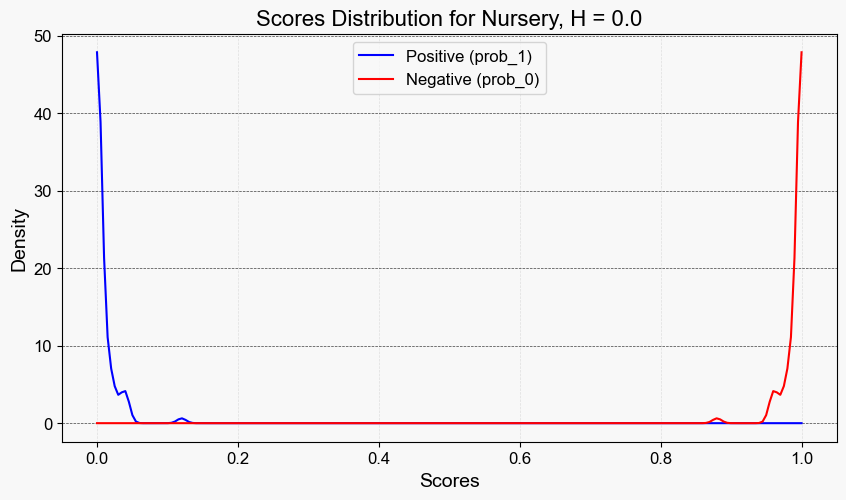

In [79]:
row = 300
H = 0.0
scores = results_df[results_df['H'] == H].iloc[3]
plot_scores(scores['test_scores'], scores['H'], title="Scores Distribution for Nursery,")

In [74]:
scores

P                                                            0.4
E                                                            1.0
H                                                            0.0
REAL                                                         0.4
PRE                                                          0.4
test_scores    [[0.14, 0.86], [0.99, 0.01], [0.13, 0.87], [0....
AE                                                           0.0
MEASURE                                                     None
DISTANCE                                                      -1
METHOD                                                    ACCSyn
Name: 273, dtype: object

## Covertype

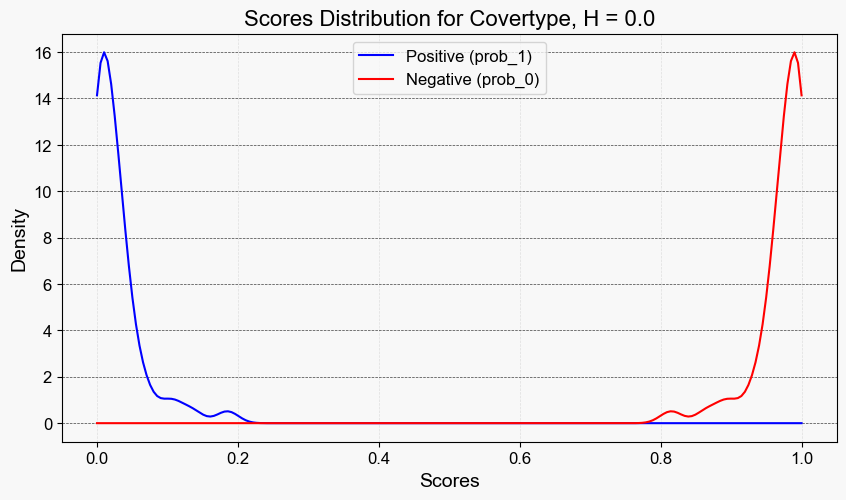

In [93]:
row = 300
H = 0.0
scores = results_df[results_df['H'] == H].iloc[0]
plot_scores(scores['test_scores'], scores['H'], title="Scores Distribution for Covertype,")

In [77]:
# p_score, n_score = results_df.iloc[0][['p_score', 'n_score']]
import plotly.graph_objects as go

def plot_histogram(p_score, n_score):
    fig_scores = go.Figure()
    fig_scores.add_trace(go.Histogram(x=p_score, name='p_score', opacity=0.7))
    fig_scores.add_trace(go.Histogram(x=n_score, name='n_score', opacity=0.7))

    fig_scores.update_layout(
        barmode='overlay',
        title='Histogram of p_score and n_score',
        xaxis_title='Score',
        yaxis_title='Count'
    )
    fig_scores.show()

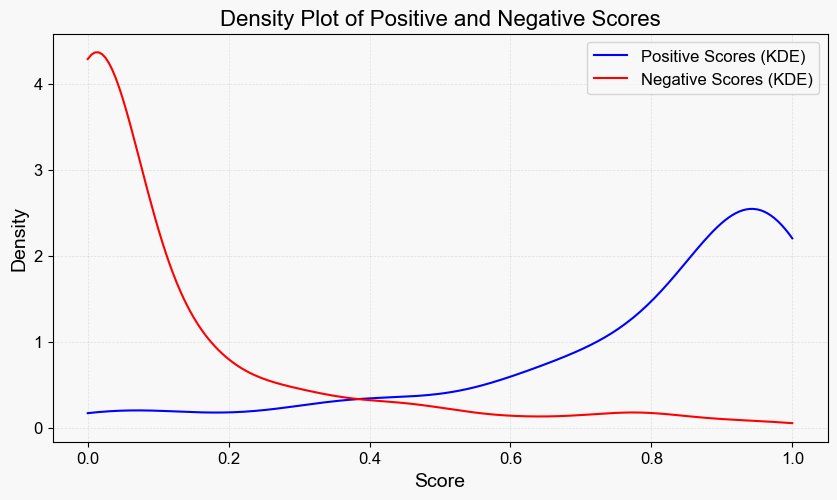

In [117]:
from scipy.stats import gaussian_kde

import matplotlib.pyplot as plt

p = scores[scores[:, 1] == 1, 0]
n = scores[scores[:, 1] == 0, 0]

def density_plot(p, n):
    # Calculate KDE for positive and negative scores
    kde_pos = gaussian_kde(p)
    kde_neg = gaussian_kde(n)

    x = np.linspace(0, 1, 200)
    plt.figure(figsize=(10, 6))
    plt.plot(x, kde_pos(x), label='Positive Scores (KDE)', color='blue')
    plt.plot(x, kde_neg(x), label='Negative Scores (KDE)', color='red')
    plt.title('Density Plot of Positive and Negative Scores')
    plt.xlabel('Score')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()

density_plot(p, n)

In [102]:
results_df['p_score'].unique

<bound method Series.unique of 0      [0.53, 0.31, 0.63, 0.03, 0.9, 0.75, 0.02, 0.07...
1      [0.53, 0.31, 0.63, 0.03, 0.9, 0.75, 0.02, 0.07...
2      [0.53, 0.31, 0.63, 0.03, 0.9, 0.75, 0.02, 0.07...
3      [0.53, 0.31, 0.63, 0.03, 0.9, 0.75, 0.02, 0.07...
4      [0.53, 0.31, 0.63, 0.03, 0.9, 0.75, 0.02, 0.07...
                             ...                        
600    [0.53, 0.31, 0.63, 0.03, 0.9, 0.75, 0.02, 0.07...
601    [0.53, 0.31, 0.63, 0.03, 0.9, 0.75, 0.02, 0.07...
602    [0.53, 0.31, 0.63, 0.03, 0.9, 0.75, 0.02, 0.07...
603    [0.53, 0.31, 0.63, 0.03, 0.9, 0.75, 0.02, 0.07...
604    [0.53, 0.31, 0.63, 0.03, 0.9, 0.75, 0.02, 0.07...
Name: p_score, Length: 605, dtype: object>

In [43]:
# p_score, n_score = results_df[results_df['H'] == 1.0].iloc[0][['p_score', 'n_score']]
# print(f"p_score: {p_score}, n_score: {n_score}")
plot_histogram(scores[scores[:, 1] == 1, 0], scores[scores[:, 1] == 0, 0])

NameError: name 'scores' is not defined

In [74]:
df

,class,att1,att2,att3,att4,att5,att6,difficulty
0,0,0,2,0,136.194861,1.452134,3334.110374,Easy
1,0,0,2,0,136.806861,1.444288,3560.921530,Easy
2,0,0,2,0,130.084861,1.576239,3396.473985,Easy
3,0,0,3,1,144.026861,1.495583,5471.785750,Easy
4,0,0,3,1,141.470861,1.515987,5416.707511,Easy
...,...,...,...,...,...,...,...,...
1595,0,1,1,1,157.498861,1.655794,5326.025889,Easy
1596,0,1,1,1,152.404861,1.620345,5243.267754,Easy
1597,0,1,1,1,134.672861,1.541987,3766.763222,Easy
1598,0,1,1,1,142.926861,1.426381,4118.327320,Easy


In [52]:
import plotly.express as px

# Create the boxplot
fig = px.box(results_df, x='METHOD', y='AE', color='METHOD', title='Boxplot of AE for ACC and ACCSyn', labels={'AE': 'Absolute Error', 'METHOD': 'Method'})
fig.show()

In [35]:
import plotly.express as px

# Create the boxplot
fig = px.box(results_df, x='METHOD', y='AE', color='METHOD', title='Boxplot of AE for ACC and ACCSyn', labels={'AE': 'Absolute Error', 'METHOD': 'Method'})
fig.show()

In [39]:
import plotly.express as px

# Create the boxplot
fig = px.box(results_df, x='METHOD', y='AE', color='METHOD', title='Boxplot of AE for ACC and ACCSyn', labels={'AE': 'Absolute Error', 'METHOD': 'Method'})
fig.show()

In [44]:
import plotly.express as px

# Create the boxplot
fig = px.box(results_df, x='METHOD', y='AE', color='METHOD', title='Boxplot of AE for ACC and ACCSyn', labels={'AE': 'Absolute Error', 'METHOD': 'Method'})
fig.show()

In [116]:
# prompt: from grouped plot a line plot where H as x axis and AE as y axis grouped by Qnt

import plotly.express as px

grouped = results_df.groupby(['METHOD', 'H']).agg({'AE': 'mean'}).reset_index()

# Assuming 're' DataFrame is already defined as in your provided code.
# If not, replace this with the actual creation of the 're' DataFrame.

# Grouped results, calculating the mean of 'AE' for each combination of 'Qnt' and 'H'
#grouped = re.groupby(['Qnt', 'H']).agg({'AE': 'mean'}).reset_index()

# Create the grouped line plot
fig = px.line(grouped, x="H", y="AE", color="METHOD", markers=True)

# Update the visibility of traces to show only ACC and ACCSyn initially
for trace in fig.data:
    if trace.name not in ["ACC", "ACCSyn"]:
        trace.visible = "legendonly"

fig.show()


In [45]:
# prompt: from grouped plot a line plot where H as x axis and AE as y axis grouped by Qnt

import plotly.express as px

grouped = results_df.groupby(['METHOD', 'H']).agg({'AE': 'mean'}).reset_index()

# Assuming 're' DataFrame is already defined as in your provided code.
# If not, replace this with the actual creation of the 're' DataFrame.

# Grouped results, calculating the mean of 'AE' for each combination of 'Qnt' and 'H'
#grouped = re.groupby(['Qnt', 'H']).agg({'AE': 'mean'}).reset_index()

# Create the grouped line plot
fig = px.line(grouped, x="H", y="AE", color="METHOD", markers=True)

# Update the visibility of traces to show only ACC and ACCSyn initially
for trace in fig.data:
    if trace.name not in ["ACC", "ACCSyn"]:
        trace.visible = "legendonly"

fig.show()
